In [90]:
import os
fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [91]:
import numpy as np

temperature = np.zeros(len(lines))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

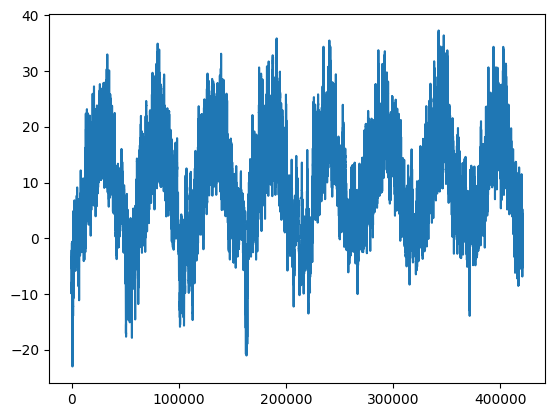

In [92]:
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)
plt.show()

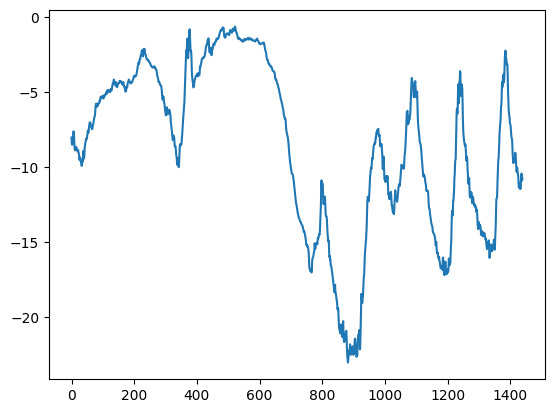

In [93]:
plt.plot(range(1440), temperature[:1440])
plt.show()

In [94]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


In [95]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [96]:
import numpy as np
from tensorflow import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]) )

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


2026-05-20 08:02:35.774290: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [97]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 -1)
batch_size = 256

In [98]:
train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples )

In [99]:
val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples )

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
    )

In [100]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


In [101]:
def evalute_naive_method(dataset):
    total_abs_err = 0
    samples_seen = 0

    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"검증 MAE: {evalute_naive_method(val_dataset):.2f}")
print(f"테스트 MAE: {evalute_naive_method(test_dataset):.2f}")

2026-05-20 08:02:42.443633: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


검증 MAE: 2.44
테스트 MAE: 2.62


2026-05-20 08:02:48.391775: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [102]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

x = layers.Reshape((sequence_length * raw_data.shape[-1],))(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

In [103]:
# 데이터셋의 실제 형태 확인
for inputs_batch, targets_batch in train_dataset.take(1):
    print(f"입력 데이터 형태: {inputs_batch.shape}")

입력 데이터 형태: (256, 120, 14)


2026-05-20 08:02:48.680190: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [104]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_dense.keras",
        save_best_only=True
    )
]

model.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["mae"],
    jit_compile=False
)

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

model = keras.models.load_model("jena_dense.keras")
print(f"테스트 MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10


819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - loss: 18.3202 - mae: 3.2358 - val_loss: 10.3590 - val_mae: 2.5472
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - loss: 9.3988 - mae: 2.4093 - val_loss: 10.3471 - val_mae: 2.5502
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - loss: 8.5306 - mae: 2.2964 - val_loss: 10.2474 - val_mae: 2.5370
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - loss: 7.9924 - mae: 2.2243 - val_loss: 10.8328 - val_mae: 2.6070
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - loss: 7.6137 - mae: 2.1716 - val_loss: 11.5460 - val_mae: 2.6884
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - loss: 7.3452 - mae: 2.1366 - val_loss: 11.6304 - val_mae: 2.6997
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 7.1758 - mae: 2.1125 - val_loss: 10.5532 - val_mae: 2.5652
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - loss: 7.0142 - mae: 2.0896 - val_loss: 11.5527 - val_mae: 2.6877
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 23

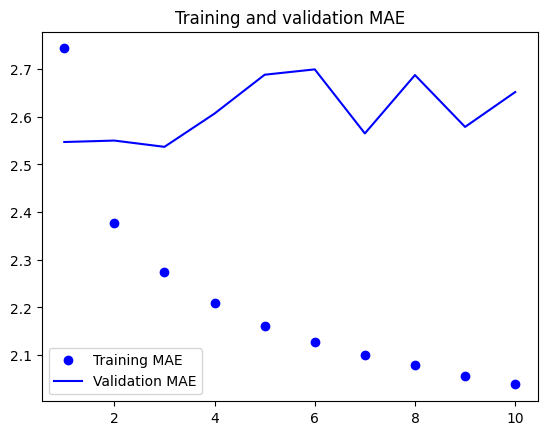

In [105]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [107]:
input = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm.keras",
        save_best_only=True
    )
]

In [108]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm.keras",
        save_best_only=True
    )
]

model.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["mae"],
    jit_compile=False
)

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

model = keras.models.load_model("jena_lstm.keras")
print(f"테스트 MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10


2026-05-20 08:07:23.266406: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8906


819/819 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - loss: 66.1055 - mae: 6.1529 - val_loss: 11.6183 - val_mae: 2.6085
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - loss: 11.4362 - mae: 2.6269 - val_loss: 9.8320 - val_mae: 2.4479
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - loss: 10.0256 - mae: 2.4662 - val_loss: 9.8046 - val_mae: 2.4411
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - loss: 9.5979 - mae: 2.4101 - val_loss: 9.5547 - val_mae: 2.3952
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - loss: 9.1425 - mae: 2.3506 - val_loss: 9.8603 - val_mae: 2.4259
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - loss: 8.8004 - mae: 2.3093 - val_loss: 9.4178 - val_mae: 2.3753
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - loss: 8.5037 - mae: 2.2729 - val_loss: 9.8896 - val_mae: 2.4295
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - loss: 8.1711 - mae: 2.2301 - val_loss: 9.7112 - val_mae: 2.4045
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 32s 38m

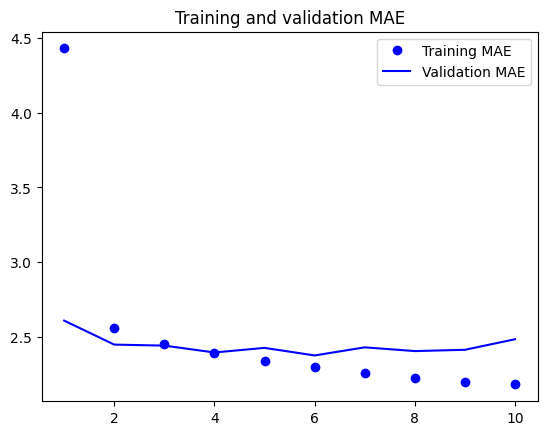

In [109]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()